# Axe 2 : Conditions de travail

---

Dans ce notebook, j'étudie les variables liées aux facteurs organisationnelles des employés afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes à l'axe
- de visualiser et retenir seulement ce qui ressort clairement.


## 1. Préparation des données de l’axe

---

Dans cette section, les variables nécessaires à l'analyse de l'axe conditions de travail sont sélectionnées et préparées à partir du jeu de données nettoyé.
Les transformations réalisées sont spécifiques à cet axe.

### 1.1 Import des librairies et chargement des données



In [1]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display_html

from pathlib import Path

In [2]:
# Définition des chemins

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

In [3]:
# chargement du df
df_clean = pd.read_parquet(PROCESSED_DATA_DIR/"employees_clean.parquet")
df_clean.head(2)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


### 1.2 Fonctions utilitaires


In [4]:
# Tableau de pourcentage variable univarié

def value_counts_percent(serie,round_n=3):

    """  Calcule la distribution (%) d'une variable catégorielle et retourne un DataFrame"""
    
    return (serie.value_counts(normalize=True).
            round(round_n).
            mul(100).
            reset_index(name="Pourcentage"))

# Tableau de pourcentage de variables bivariés
def groupby_percent(df,columns1,columns2,observed=True):
    """Calcule la distribution (%) de columns2 pour chaque modalité de columns1
    et retourne un DataFrame au format long. """
    return(df.groupby(columns1,observed=observed)[columns2].
           value_counts(normalize=True).
           round(2)
           *100).reset_index(name="Pourcentage")

# Tableau de moyenne de variable bivariés
def groupby_mean(df, columns1, columns2) :
    """Calcul la moyenne de distribution de columns2 pour chaque modalité de columns1
    et retourne un dataFrame """
    return(df.groupby(columns1, observed=True)[columns2].mean().round(2).reset_index(name="Moyenne"))

# Table pivot en pourcentage de variables bivarié
def pivot_percent(df,index,columns):
    """ Crée un tableau pivot (%) : lignes=index, colonnes=columns."""
    df = groupby_percent(df,index,columns)
    return(df.pivot(index=index, columns=columns,values="Pourcentage").fillna(0))


### 1.3 Création du DataFrame Condition de travail

#### Colonnes incluses dans l'axe "Condition de travail"

Cet axe regroupe les caractéristiques organisationnelles :
- BusinessTravel 
- Department 
- JobLevel 
- JobRole 
- MonthlyIncome 
- OverTime 
- PercentSalaryHike 
- StockOptionLevel
- TotalWorkingYears
- TrainingTimesLastYear 
- YearsAtCompany 
- YearsInCurrentRole 
- YearsSinceLastPromotion 
- YearsWithCurrManager 
 
Ces variables décrivent le contexte organisationnel susceptible d'influencer l'attrition.

In [5]:
# colonnes condition de travail
cols_conditions_travail = ['BusinessTravel', 'Department','JobLevel',"JobRole",'MonthlyIncome','OverTime','PercentSalaryHike','StockOptionLevel',
             "TotalWorkingYears", "TrainingTimesLastYear", "YearsAtCompany","YearsInCurrentRole","YearsSinceLastPromotion","YearsWithCurrManager","EmployeeNumber"]

# Création df_conditions_travail
df_conditions_travail = df_clean[cols_conditions_travail + ['Attrition']].copy()
df_conditions_travail.head(3)


,BusinessTravel,Department,JobLevel,JobRole,MonthlyIncome,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeNumber,Attrition
0,Travel_Rarely,Sales,2,Sales Executive,5993,Yes,11,0,8,0,6,4,0,5,1,Yes
1,Travel_Frequently,Research & Development,2,Research Scientist,5130,No,23,1,10,3,10,7,1,7,2,No
2,Travel_Rarely,Research & Development,1,Laboratory Technician,2090,Yes,15,0,7,3,0,0,0,0,4,Yes


### 1.4 Préparation des variables

**Actions :**
- Renommage pour la lisibilité
- Création de tranches
- Regroupements : Les seuils de regroupement peuvent différer selon les sous-thèmes afin de s'adapter à la distribution spécifique de chaque variable et à leur interprétation métier.


**Renommage des niveaux hiérarchiques (JobLevel)**

La variable *JobLevel*, codée de 1 à 5 dans le jeu de données, a été renommée en niveaux hiérarchiques allant de **niveau hiérarchique bas** à **niveau hiérarchique très senior**, afin d'en faciliter l'interprétation.  

Le niveau hiérarchique correspond au niveau du poste occupé et non à l'ancienneté ou à l'expérience totale, comme le montrent certaines observations où des employés de niveau hiérarchique bas présentent plusieurs années d'expérience.  

En l'absence de définition officielle fournie dans la documentation, ce renommage reste volontairement descriptif et neutre.


In [6]:
joblevel_name = {1 : "Niveau hiérarchique bas",
                2 : "Niveau hiérarchique intermédiaire",
                3 : "Niveau hiérarchique confirmé",
                4 : "Niveau hiérarchique senior",
                5 : "Niveau hiérarchique très senior"}

df_conditions_travail["JobLevel_label"] = df_conditions_travail["JobLevel"].replace(joblevel_name)
df_conditions_travail.JobLevel_label.head(2)

0    Niveau hiérarchique intermédiaire
1    Niveau hiérarchique intermédiaire
Name: JobLevel_label, dtype: object

**Transformation des Heures supplémentaire en variable numérique**

La variable *Overtime*, initialement codée sous forme catégorielle ("Yes"/"No"), a été transformée en variable numérique binaire (1/0) afin de faciliter les analyses quantitatives et le calcul de taux moyens.


In [7]:
df_conditions_travail["OverTime_num"]= df_conditions_travail["OverTime"].map({"No": 0, "Yes": 1})
df_conditions_travail.head(2)

,BusinessTravel,Department,JobLevel,JobRole,MonthlyIncome,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeNumber,Attrition,JobLevel_label,OverTime_num
0,Travel_Rarely,Sales,2,Sales Executive,5993,Yes,11,0,8,0,6,4,0,5,1,Yes,Niveau hiérarchique intermédiaire,1
1,Travel_Frequently,Research & Development,2,Research Scientist,5130,No,23,1,10,3,10,7,1,7,2,No,Niveau hiérarchique intermédiaire,0


**Création des tranches des revenus mensuelle (MonthlyIncome)**

Le revenu mensuel est une variable continue dont la distribution est fortement étalée.  
Afin de faciliter l'analyse et de rendre les résultats plus lisibles d'un point de vue RH, les revenus ont été regroupés en tranches interprétables, basées sur la médiane et sur des seuils cohérents en termes de niveaux de rémunération.

Ces tranches ne visent pas à répartir les effectifs de manière strictement équilibrée, mais à distinguer des profils de rémunération comparables :

- **Faible niveau de rémunération** : < 2 500  
- **Niveau de rémunération intermédiaire bas** : 2 500 - 5 000  
- **Niveau de rémunération intermédiaire haut** : 5 000 - 7 500  
- **Niveau de rémunération élevé** : > 7 500  

Ces tranches permettront d'analyser plus clairement la relation entre le revenu mensuel et l'attrition.

In [8]:
df_conditions_travail["Tranche_Salaire"]= pd.cut(
        df_conditions_travail["MonthlyIncome"],
        bins=[0, 2500, 5000, 7500, 20000],
        labels=["< 2 500", "2 500 - 5 000", "5 000 - 7 500" , "> 7 500"],
        ordered=True,
        include_lowest=True)
df_conditions_travail.Tranche_Salaire.head(2)


0    5 000 - 7 500
1    5 000 - 7 500
Name: Tranche_Salaire, dtype: category
Categories (4, object): ['< 2 500' < '2 500 - 5 000' < '5 000 - 7 500' < '> 7 500']

**Création des tranches du pourcentage d'augmentation de salaire (PercentSalaryHike)**

Pour faciliter l'analyse exploratoire et rendre les visualisations plus lisibles, le pourcentage d'augmentation de salaire a été regroupé en tranches cohérentes :

- **Faible niveau d'augmentation de salaire** : < 12  
- **Niveau d'augmentation de salaire intermédiaire** : 12 - 15  
- **Niveau d'augmentation de salaire intermédiaire haut** : 15 - 18  
- **Niveau d'augmentation de salaire élevé** : > 18  

Ces catégories permettent d'identifier plus facilement d'éventuelles relations entre le pourcentage d'augmentation de salaire et l'attrition.


In [9]:
df_conditions_travail["Tranche_PercentSalaryHike"]= pd.cut(
        df_conditions_travail["PercentSalaryHike"],
        bins=[0, 12, 15, 18, 30],
        labels=["< 12", "12-15", "15-18", "> 18"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_PercentSalaryHike.head(2)

0    < 12
1    > 18
Name: Tranche_PercentSalaryHike, dtype: category
Categories (4, object): ['< 12' < '12-15' < '15-18' < '> 18']

**Renommage des niveaux de stock-options (StockOptionLevel)**

La variable *StockOptionLevel*, codée de 0 à 3 dans le jeu de données, a été renommée afin d'en améliorer la lisibilité.  
Les niveaux de stock-options sont traités comme une variable catégorielle ordonnée, sans hypothèse sur leur valeur monétaire.

In [10]:
stockOptionLevel_name = {
    0 : "Aucun",
    1 : "Niveau 1",
    2 : "Niveau 2",
    3 : "Niveau 3"
}
df_conditions_travail["StockOptionLevel_label"] = df_conditions_travail["StockOptionLevel"].replace(stockOptionLevel_name)
df_conditions_travail.StockOptionLevel_label.head(3)


0       Aucun
1    Niveau 1
2       Aucun
Name: StockOptionLevel_label, dtype: object

**Création des tranches pour l'ancienneté dans l'entreprise (YearsAtCompany)**

L'ancienneté dans l'entreprise est une variable continue dont la distribution est relativement étalée. Afin de faciliter l'analyse et d'améliorer la lisibilité des résultats d'un point de vue RH, cette variable a été regroupée en tranches interprétables, basées sur des seuils cohérents avec les étapes classiques d'un parcours professionnel.

- **Nouveaux salariés** : ≤ 2 ans
- **Ancienneté courte** : 3 - 5 ans
- **Ancienneté intermédiaire** : 6 - 10 ans
- **Ancienneté longue** : 11 - 15 ans
- **Ancienneté très longue** : 16 - 20 ans
- **Ancienneté exceptionnelle** : > 20 ans

Ces catégories permettent de distinguer les phases d'intégration, de stabilisation et de fidélisation des salariés, et facilitent l'identification d'éventuelles relations entre l'ancienneté dans l'entreprise et l'attrition.


In [11]:
df_conditions_travail["Tranche_Anciennete"] = pd.cut(
        df_conditions_travail["YearsAtCompany"],
        bins=[0, 2, 5, 10, 15, 20, 100],
        labels=["≤ 2 ans", "3-5 ans", "6-10 ans", "11-15 ans", "16-20 ans", "> 20 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_Anciennete.head(2)

0    6-10 ans
1    6-10 ans
Name: Tranche_Anciennete, dtype: category
Categories (6, object): ['≤ 2 ans' < '3-5 ans' < '6-10 ans' < '11-15 ans' < '16-20 ans' < '> 20 ans']

**Création des tranches pour l'ancienneté dans le poste actuel de l'employé (YearsInCurrentRole)** 

L'ancienneté dans le poste actuel est une variable continue dont la distribution est relativement étalée. Afin de faciliter l'analyse exploratoire et d'améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux différentes phases d'occupation d'un poste.

- **Prise de poste récente** : ≤ 2 ans
- **Poste stabilisé** : 3 - 5 ans
- **Poste confirmé** : 6 - 10 ans
- **Poste très expérimenté** : > 10 ans

Ces catégories permettent d'identifier plus facilement d'éventuelles relations entre l'ancienneté dans le poste et l'attrition.

In [12]:
df_conditions_travail["Tranche_PosteAnciennete"] = pd.cut(
        df_conditions_travail.YearsInCurrentRole,
        bins=[0, 2, 5, 10, 100],
        labels=["≤ 2 ans", "3-5 ans", "6-10 ans", "> 10 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_PosteAnciennete.head(2)

0     3-5 ans
1    6-10 ans
Name: Tranche_PosteAnciennete, dtype: category
Categories (4, object): ['≤ 2 ans' < '3-5 ans' < '6-10 ans' < '> 10 ans']

**Création des tranches pour le nombre total d'expériences professionnelle de l'employé  (TotalWorkingYears)** 

L'expérience professionnelle totale du salarié est une variable continue dont la distribution est relativement étalée. Afin de faciliter l'analyse exploratoire et d'améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux grandes étapes d'un parcours professionnel.

- **Expérience professionnelle très récente** : ≤ 2 ans
- **Expérience professionnelle courte** : 3 - 5 ans
- **Expérience professionnelle intermédiaire** : 6 - 10 ans
- **Expérience professionnelle longue** : 11 - 15 ans
- **Expérience professionnelle très longue** : > 15 ans


Les catégories permettent de mieux décrire la répartition des employés selon leur expérience professionnelle globale et de faciliter l'identification d'éventuelles relations avec l'attrition.

In [13]:
df_conditions_travail["Tranche_ExperiencePro"] = pd.cut(
        df_conditions_travail.TotalWorkingYears,
        bins=[0, 2, 5, 10, 15, 100],
        labels=["≤ 2 ans", "3-5 ans", "6-10 ans", "11-15 ans", "> 15 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_ExperiencePro.head(2)

0    6-10 ans
1    6-10 ans
Name: Tranche_ExperiencePro, dtype: category
Categories (5, object): ['≤ 2 ans' < '3-5 ans' < '6-10 ans' < '11-15 ans' < '> 15 ans']

**Création des tranches pour le nombre d'années écoulées depuis la dernière promotion (YearsSinceLastPromotion)**

La variable *YearsSinceLastPromotion* est une variable continue dont la distribution est relativement étalée. Afin de faciliter l'analyse exploratoire et d'améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux grandes étapes d'un parcours professionnel.

- **Promotion très récente** : < 1 an
- **Promotion récente** : 1-2 ans
- **Promotion intermédiaire** : 3-5 ans
- **Promotion longue** : 6-10 ans
- **Promotion très longue** : > 10 ans


Ces catégories permettent de mieux décrire la répartition des employés selon le délai écoulé depuis leur dernière promotion et de faciliter l'identification d'éventuelles relations avec l'attrition.

In [14]:
df_conditions_travail["Tranche_LastPromotion"] = pd.cut(
        df_conditions_travail.YearsSinceLastPromotion,
        bins=[0, 1, 2, 5, 10, 100 ],
        labels=["< 1 an", "1-2 ans", "3-5 ans", "6-10 ans", "> 10 ans"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.Tranche_LastPromotion.head(2)

0    < 1 an
1    < 1 an
Name: Tranche_LastPromotion, dtype: category
Categories (5, object): ['< 1 an' < '1-2 ans' < '3-5 ans' < '6-10 ans' < '> 10 ans']

**Création des tranches pour la durée de collaboration avec le manager actuel (YearsWithCurrManager)**

La variable *YearsWithCurrManager* est une variable continue dont la distribution est relativement étalée. Afin de faciliter l'analyse exploratoire et d'améliorer la lisibilité des visualisations, cette variable a été regroupée en tranches cohérentes correspondant aux grandes étapes de la collaboration entre un employé et son manager actuel.

- **Collaboration très récente** : < 1 an
- **Collaboration récente** : 1 - 2 ans
- **Collaboration intermédiaire** : 3 - 5 ans
- **Collaboration longue** : 6 - 10 ans
- **Collaboration très longue** : > 10 ans

Ces catégories permettent de mieux décrire la répartition des employés selon la durée de collaboration avec leur manager actuel et de faciliter l'identification d'éventuelles relations avec l'attrition.

In [15]:
df_conditions_travail["Tranche_CurManager"] = pd.cut(
        df_conditions_travail.YearsWithCurrManager,
        bins=[0, 1, 2, 5, 10, 100],
        labels=["< 1 ans", "1-2 ans", "3-5 ans ", "6-10 ans", "> 10 ans"],
        ordered=True,
        include_lowest=True) 

df_conditions_travail.Tranche_CurManager.head(2)

0    3-5 ans 
1    6-10 ans
Name: Tranche_CurManager, dtype: category
Categories (5, object): ['< 1 ans' < '1-2 ans' < '3-5 ans ' < '6-10 ans' < '> 10 ans']

### 1.5 Sauvegarde du DataFrame


In [16]:
df_conditions_travail.to_parquet(PROCESSED_DATA_DIR/"df_conditions_travail.parquet",index=False)

## 2 Analyse individuelle des variables 

---

Dans cette section, l'analyse porte sur plusieurs caractéristiques des conditions de travail des employés, afin de mieux comprendre le contexte organisationnel de la population étudiée.

Les variables sont analysées selon différents sous-thèmes :
- la structure du poste,
- la rémunération,
- l'ancienneté et la carrière,
- le management et l'évolution professionnelle.

Certaines variables seront analysées de manière plus approfondie que d'autres.
Cette analyse repose sur une approche **descriptive**, basée sur l'étude des **distributions**, à l'aide de **tableaux de proportions** et de **visualisations graphiques**.

Pour compléter l'analyse catégorielle, une moyenne des scores de certaines variables organisationnelles sont calculées comme indicateur synthétique.


### 2.1 Structure du poste

Cette section est consacrée à l'exploration des variables liées à la **structure du poste**, qui regroupent les caractéristiques organisationnelles du travail et certaines conditions professionnelles des employés.

Les variables étudiées sont les suivantes :

- **Department** : correspond au département de rattachement de l'employé au sein de l'entreprise.
- **JobRole** : désigne le poste occupé par l'employé.
- **JobLevel** : indique le niveau hiérarchique ou le niveau de poste de l'employé.
- **BusinessTravel** : représente la fréquence des déplacements professionnels effectués par l'employé.
- **OverTime** : précise si l'employé effectue ou non des heures supplémentaires.

Dans le cadre de cette analyse :
- **BusinessTravel**, **Department** et **JobLevel** feront l'objet d'une analyse descriptive légère.
- **JobRole** et **OverTime** seront analysées de manière plus détaillée.


Les variables de ce sous-thème sont décrites à travers leurs répartitions afin de mieux comprendre la structure des postes au sein de l'entreprise.

**Département de rattachement de l'employé (department)**

**Tableau des proportions**

In [1]:
department_count = value_counts_percent(df_conditions_travail["Department"])
department_count

NameError: name 'value_counts_percent' is not defined

Les employés sont répartis en trois départements.  
Le département majoritaire est **Research & Development**, suivi du département **Sales**, tandis que le département **Human Resources** est minoritaire.

**Le poste occupé par l'employé (jobRole)**

**Tableau des proportions**

In [18]:
jobRole_count = value_counts_percent(df_conditions_travail["JobRole"])
jobRole_count

,JobRole,Pourcentage
0,Sales Executive,22.2
1,Research Scientist,19.9
2,Laboratory Technician,17.6
3,Manufacturing Director,9.9
4,Healthcare Representative,8.9
5,Manager,6.9
6,Sales Representative,5.6
7,Research Director,5.4
8,Human Resources,3.5


**Distribution des employés selon leur fonction**

Ce graphique montre que trois fonctions sont particulièrement représentées :
- **Sales Executive** (≈22 %)
- **Research Scientist** (≈20 %)
- **Laboratory Technician** (≈18 %)

Les fonctions minoritaires sont **Human Resources** (≈4 %) et **Research Director** / **Sales Representative** (≈5-6 %).

Cette exploration permet d'avoir une première vision des fonctions présentes dans l'entreprise et d'apprécier la diversité des profils métiers.

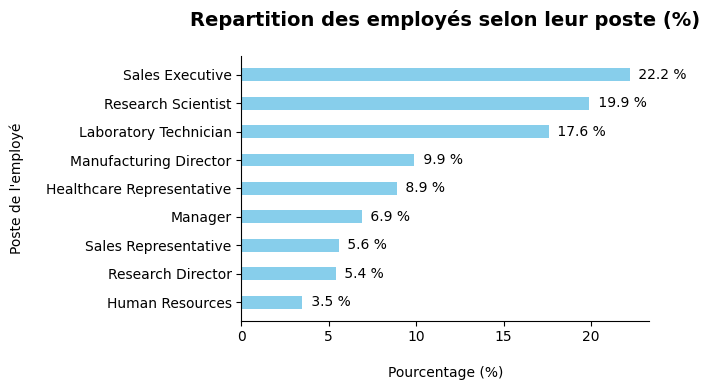

(None,)

In [19]:
jobRole_count =jobRole_count.sort_values("Pourcentage", ascending=True)

fig , ax = plt.subplots(figsize=(7,4))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(jobRole_count["JobRole"]))
y = jobRole_count["Pourcentage"]

# Barplot
barhs = ax.barh(x, y, height=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} %' for v in y ], padding=3)

# axes et labels
ax.set_yticks(x)
ax.set_yticklabels(jobRole_count["JobRole"])

ax.set_xlabel("\nPourcentage (%)")
ax.set_ylabel("Poste de l'employé\n")
ax.set_title("Repartition des employés selon leur poste (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


**Le niveau hiérarchique (Joblevel)**

**Tableau des proportions**

In [20]:
jobLevel_count = value_counts_percent(df_conditions_travail["JobLevel_label"])
jobLevel_count

,JobLevel_label,Pourcentage
0,Niveau hiérarchique bas,36.9
1,Niveau hiérarchique intermédiaire,36.3
2,Niveau hiérarchique confirmé,14.8
3,Niveau hiérarchique senior,7.2
4,Niveau hiérarchique très senior,4.7


On observe que la majorité des employés occupent un **niveau hiérarchique bas** ou **intermédiaire** (≈73 %).  
À l'inverse, les employés ayant un **niveau hiérarchique très senior** représentent environ **5 %** de l'effectif.

**Les déplacements professionnels (BusinessTravel)**

**Tableau des proportions**


In [21]:
businesstravel_count = value_counts_percent(df_conditions_travail["BusinessTravel"])
businesstravel_count

,BusinessTravel,Pourcentage
0,Travel_Rarely,71.0
1,Travel_Frequently,18.8
2,Non-Travel,10.2


On observe qu'une large majorité des employés déclarent **voyager rarement pour des raisons professionnelles** (≈71 %).  
À l'inverse, environ **10 %** des salariés déclarent ne **jamais effectuer de déplacements professionnels**.

**Les heures Supplémentaires (Overtime)**

**Tableau des proportions**

In [22]:
overtime_count = value_counts_percent(df_conditions_travail["OverTime"])
overtime_count

,OverTime,Pourcentage
0,No,71.7
1,Yes,28.3


**Distribution des employés en fonctions des heures supplémentaires.**

On observe qu'une majorité des employés (**environ 72 %**) déclarent effectuer des heures supplémentaires au sein de l'entreprise.

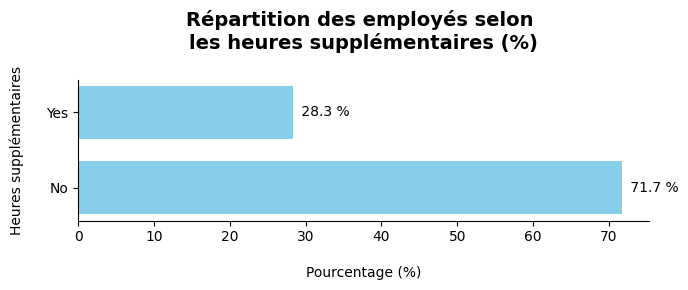

(None,)

In [23]:
fig, ax = plt.subplots(figsize=(7,3))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x= np.arange(len(overtime_count.index))
y = overtime_count["Pourcentage"]

# barplot
barhs = ax.barh(x, y, height=0.7, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} %' for v in y], padding=3)

# axes et labels
ax.set_yticks(x)
ax.set_yticklabels(overtime_count["OverTime"])


ax.set_xlabel("\nPourcentage (%)")
ax.set_ylabel("Heures supplémentaires\n")
ax.set_title("Répartition des employés selon \nles heures supplémentaires (%)\n", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

**Mini-synthèse - Structure du poste**

L'analyse de la structure des postes offre une première vision du contexte organisationnel de l'entreprise.
Les employés sont majoritairement répartis entre les départements **Research & Development** et **Sales**, ce qui est cohérent avec les postes les plus représentés, tels que **Sales Executive**, **Research Scientist** et **Laboratory Technician**.

La majorité des employés (environ **70 %**) occupent des niveaux hiérarchiques **bas ou intermédiaires** et déclarent **voyager rarement** pour des raisons professionnelles.

Par ailleurs, près de **trois quarts des employé**s déclarent effectuer **des heures supplémentaires**, ce qui caractérise une organisation du travail dans laquelle cette pratique est largement répandue.

Après avoir décrit la structure des postes au sein de l'entreprise, l'analyse se poursuit avec les variables liées à la rémunération, afin de caractériser les niveaux de revenus et les éléments financiers associés aux conditions de travail.

#### 2.2 Rémunération

Cette section s'intéresse aux variables liées à la **rémunération et aux éléments financiers associés**.

Les variables analysées sont :

- **MonthlyIncome** : correspond au revenu mensuel de l'employé.
- **PercentSalaryHike** : indique le pourcentage d'augmentation de salaire.
- **StockOptionLevel** : représente le niveau d'options d'actions attribuées à l'employé.

Dans le cadre de cette analyse :
- **StockOptionLevel** fera l'objet d'une analyse descriptive légère.
- **MonthlyIncome--- et **PercentSalaryHike** seront analysées de manière plus détaillée.

 
Ces variables sont analysées de manière descriptive afin de caractériser la distribution des niveaux de rémunération au sein de l'entreprise.

**Le revenu mensuel de l'employé (MonthlyIncome)**

**Tableau des proportions**

In [24]:
MonthlyIncome_count = value_counts_percent(df_conditions_travail["Tranche_Salaire"])
MonthlyIncome_count 


,Tranche_Salaire,Pourcentage
0,2 500 - 5 000,35.6
1,> 7 500,28.0
2,5 000 - 7 500,21.1
3,< 2 500,15.4


**Distribution des employés en fonctions de leur revenu mensuel**

Ce graphique montre que deux tranches de revenu sont particulièrement représentées :
- la tranche **2 500 - 5 000** (≈36 %),
- la tranche **> 7 500** (≈28 %).

Les tranches plus minoritaires sont **5 000 - 7 500** (≈21 %) et **< 2 500** (≈15 %).

Cette exploration met en évidence les grandes lignes de l'échelle salariale et permet d'apprécier la diversité des profils de rémunération au sein de l'entreprise.


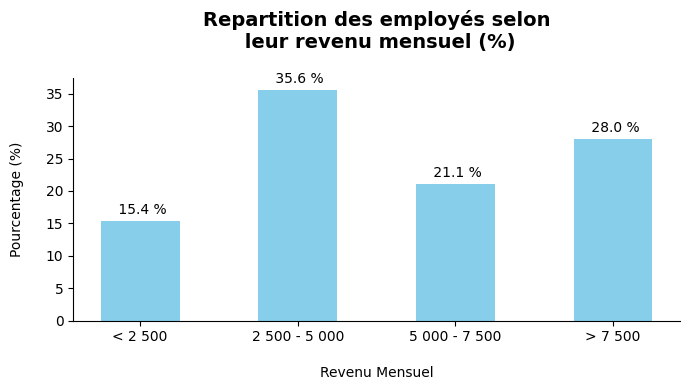

(None,)

In [25]:
MonthlyIncome_count = MonthlyIncome_count.sort_values("Tranche_Salaire", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(MonthlyIncome_count.index))
y = MonthlyIncome_count["Pourcentage"]

# Barplot
barhs = ax.bar(x, y, width=0.5, color="skyblue")

# Pourcentage
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(MonthlyIncome_count["Tranche_Salaire"])
ax.set_xlabel("\nRevenu Mensuel")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Repartition des employés selon\n leur revenu mensuel (%)\n ", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

**Le pourcentage d'augmentation de salaire de l'employé (PercentSalaryHike)**

**Tableau des proportions**

In [26]:
PercentSalaryHike_count = value_counts_percent(df_conditions_travail["Tranche_PercentSalaryHike"])
PercentSalaryHike_count

,Tranche_PercentSalaryHike,Pourcentage
0,12-15,34.8
1,< 12,27.8
2,> 18,20.5
3,15-18,16.9


**Distribution des employés selon leur pourcentage d'augmentation de salaire**

Ce graphique montre que deux tranches sont particulièrement représentées :
- la tranche **12-15 %** d'augmentation de salaire (≈35 %),
- la tranche **< 12 %** (≈28 %).

Les tranches plus minoritaires sont **> 18 %** (≈21 %) et **15-18 %** (≈17 %).

Cette exploration permet d'avoir une première vision des niveaux d'augmentation de salaire au sein de l'entreprise.


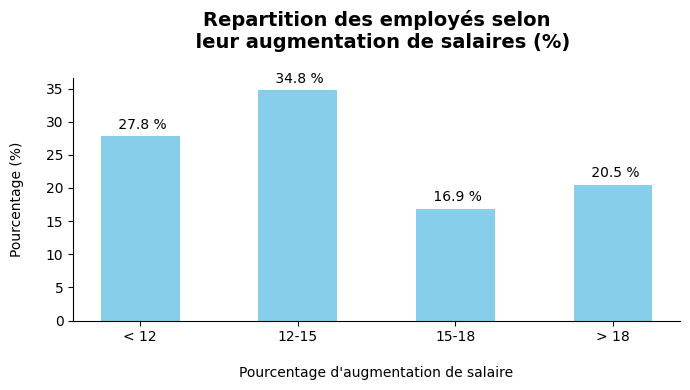

(None,)

In [27]:
PercentSalaryHike_count = PercentSalaryHike_count.sort_values("Tranche_PercentSalaryHike", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(PercentSalaryHike_count.index))
y = PercentSalaryHike_count["Pourcentage"]

# Barplot
barhs = ax.bar(x, y, width=0.5, color="skyblue")

# Pourcentage
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(PercentSalaryHike_count["Tranche_PercentSalaryHike"])
ax.set_xlabel("\nPourcentage d'augmentation de salaire")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Repartition des employés selon\n  leur augmentation de salaires (%)\n", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

**Le niveau de stock-option attribué à l'employé (StockOptionLevel)**

**Tableau des proportions**

In [28]:
stockOptionLevel_count = value_counts_percent(df_conditions_travail["StockOptionLevel_label"])
stockOptionLevel_count

,StockOptionLevel_label,Pourcentage
0,Aucun,42.9
1,Niveau 1,40.5
2,Niveau 2,10.7
3,Niveau 3,5.8


On observe que la majorité des employés ne bénéficient **d'aucune stock-option** ou disposent d'un **niveau 1 de stock-options** (≈83 %).  

À l'inverse, les employés ayant un **niveau 3 de stock-options** représentent environ **6 %** de l'effectif.

Cette exploration met en évidence les grandes lignes d'un élément de rémunération variable attribué à une partie limitée des salariés.

**Mini-synthèse - Rémunération**

L'analyse de la rémunération met en évidence une distribution **hétérogène** des revenus mensuels au sein de l'entreprise.
Une part importante des employés se situe dans des tranches de rémunération **intermédiaires**, tandis qu'une proportion non négligeable appartient aux tranches **de revenus élevés**.

Les augmentations de salaire sont principalement concentrées sur **des niveaux faibles à intermédiaire**, les hausses les plus élevées restant minoritaires.

Enfin, la majorité des employés ne bénéficie **d'aucune ou de faibles stock-options**, ces dispositifs concernant une population restreinte.


#### 2.3 Ancienneté et carrière

Cette section porte sur les variables décrivant l'**ancienneté** et le **parcours professionnel** des employés.

Les variables étudiées sont :

- **YearsAtCompany** : représente le nombre d'années passées par l'employé dans l'entreprise.
- **YearsInCurrentRole** : correspond à l'ancienneté dans le poste actuel.
- **TotalWorkingYears** : indique le nombre total d'années d'expérience professionnelle.

Dans le cadre de cette analyse :
- **YearsInCurrentRole** fera l'objet d'une analyse descriptive légère.
- **YearsAtCompany--- et **TotalWorkingYearse** seront analysées de manière plus détaillée.


L'analyse de ces variables permet de décrire le niveau d'expérience et l'ancienneté des employés au sein de l'organisation.

**L'ancienneté dans l'entreprise (YearsAtCompany)**

**Tableau des proportions**

In [29]:
YearsAtCompany_count = value_counts_percent(df_conditions_travail["Tranche_Anciennete"])
YearsAtCompany_count


,Tranche_Anciennete,Pourcentage
0,6-10 ans,30.5
1,3-5 ans,29.5
2,≤ 2 ans,23.3
3,11-15 ans,7.3
4,16-20 ans,4.9
5,> 20 ans,4.5


**Distribution des employés en fonctions de leur ancienneté**

Ce graphique montre que deux tranches d'ancienneté sont particulièrement représentées :
- la tranche **6-10 ans** (≈31 %),
- la tranche **3-5 ans** (≈30 %).

Les tranches plus minoritaires sont **> 20 ans** et **16-20 ans** (≈5 %). À noter que la tranche **des nouveaux salariés (< 2 ans)** représentent environ 23 %.

Cette exploration permet d'avoir une première vision de la dynamique interne de l'entreprise.

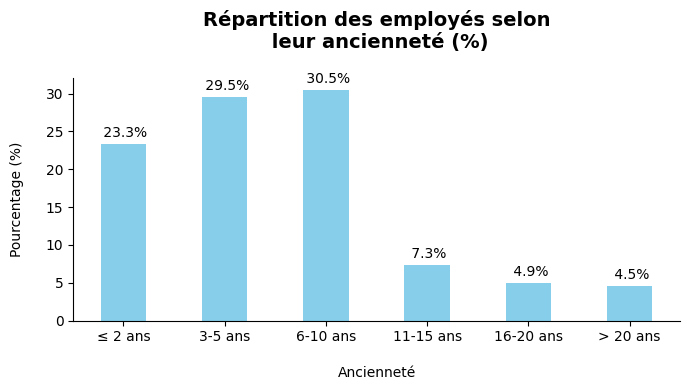

In [30]:
YearsAtCompany_count = YearsAtCompany_count.sort_values("Tranche_Anciennete", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(YearsAtCompany_count.index))
y = YearsAtCompany_count.Pourcentage

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché

ax.bar_label(bars, labels=[f"{v : .1F}%" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(YearsAtCompany_count.Tranche_Anciennete)
ax.set_xlabel("\nAncienneté")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Répartition des employés selon\n leur ancienneté (%)\n", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**L'ancienneté dans le poste actuel des salariés (YearsInCurrentRole)**

**Tableau des proportions**

In [31]:
yearsInCurrentRole_count = value_counts_percent(df_conditions_travail.Tranche_PosteAnciennete)
yearsInCurrentRole_count

,Tranche_PosteAnciennete,Pourcentage
0,≤ 2 ans,45.8
1,6-10 ans,30.2
2,3-5 ans,18.7
3,> 10 ans,5.3


On observe que deux tranches d'ancienneté dans le poste sont particulièrement représentées à elles deux, ces tranches représentent environ **76 %** des effectifs
- la tranche **≤ 2 ans** (≈46 %),
- la tranche **6-10 ans** (≈30 %).

Les tranches plus minoritaires sont **> 10 ans** (≈5 %) et la tranche **3-5 ans** (≈19 %). 

Cette exploration permet de dégager les grandes tendances relatives à la durée d'occupation du poste actuel par les employés de l'entreprise.

**le nombre total d'années d'expérience professionnelle (TotalWorkingYears)**

**Tableau des proportions**

In [32]:
TotalWorkingYear_count = value_counts_percent(df_conditions_travail.Tranche_ExperiencePro)
TotalWorkingYear_count

,Tranche_ExperiencePro,Pourcentage
0,6-10 ans,41.3
1,> 15 ans,24.2
2,3-5 ans,13.1
3,11-15 ans,13.0
4,≤ 2 ans,8.4


**Distribution des employés en fonctions de leurs expériences professionnelle totale.**

Ce graphique met en évidence une tranche d'expérience professionnelle particulièrement représentée : **la tranche 6-10 ans**, qui regroupe environ **41 %** des employés. Elle est suivie par **la tranche supérieure à 15 ans**, représentant **approximativement 24 %** de l'effectif.

À l'inverse, **la tranche ≤ 2 ans** apparaît comme la moins représentée, avec **approximativement 8 %** des employés.

Cette exploration descriptive permet d'obtenir une première vision de la répartition de l'expérience professionnelle au sein de l'entreprise.

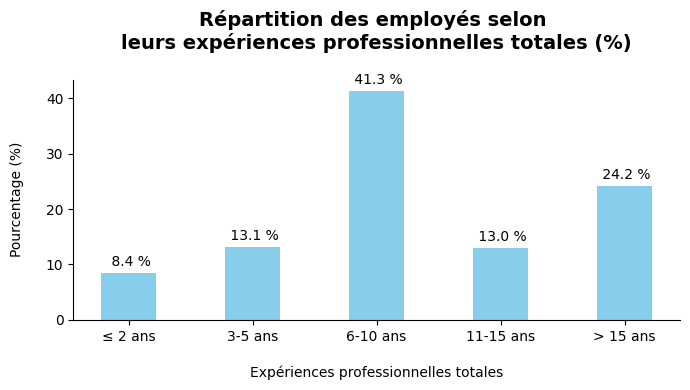

(None,)

In [33]:
TotalWorkingYear_count = TotalWorkingYear_count.sort_values("Tranche_ExperiencePro", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données 
x = np.arange(len(TotalWorkingYear_count.index))
y = TotalWorkingYear_count.Pourcentage

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(TotalWorkingYear_count.Tranche_ExperiencePro)

ax.set_xlabel("\nExpériences professionnelles totales")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Répartition des employés selon \nleurs expériences professionnelles totales (%)\n",
             fontsize=14,fontweight="bold")

fig.tight_layout()
plt.show(),

**Mini-synthèse - Ancienneté et carrière**

L'analyse de l'ancienneté et du parcours professionnel met en évidence une population composée majoritairement d'employés ayant une ancienneté comprise **entre 0 et 10 ans** au sein de l'entreprise.
Les employés avec une ancienneté supérieure à 10 ans sont nettement moins représentés.

L'ancienneté dans le poste actuel est majoritairement **récente ou intermédiaire**, tandis que les postes occupés depuis plus de 10 ans restent minoritaires.

En termes d'expérience professionnelle totale, les employés présentent majoritairement des niveaux **intermédiaires à élevés**, alors que les profils très peu expérimentés sont peu représentés.

#### 2.4 Management et évolution


Cette dernière section explore les variables relatives au **management** et aux **aspects de l'évolution professionnelle**

Les variables analysées sont :

- **YearsSinceLastPromotion** : indique le nombre d'années écoulées depuis la dernière promotion de l'employé.
- **TrainingTimesLastYear** : correspond au nombre de formations suivies au cours de l'année précédente.
- **YearsWithCurrManager** : représente la durée de collaboration avec le manager actuel.

Dans le cadre de cette analyse :
- **TrainingTimesLastYear** et **YearsWithCurrManager** feront l'objet d'une analyse descriptive légère.
- **YearsSinceLastPromotion** sera analysée de manière plus détaillée.

Ces variables sont décrites afin de mieux caractériser le contexte managérial et les parcours d'évolution au sein de l'entreprise.

**Le nombre d'années écoulées depuis leur dernière promotion (YearsSinceLastPromotion)**

**Tableau des proportions**

In [34]:
yearsSinceLastPromotion_count = value_counts_percent(df_conditions_travail.Tranche_LastPromotion)
yearsSinceLastPromotion_count

,Tranche_LastPromotion,Pourcentage
0,< 1 an,63.8
1,1-2 ans,10.8
2,3-5 ans,10.7
3,6-10 ans,10.1
4,> 10 ans,4.5


**Distribution des employés en fonctions du délai écoulé depuis leur dernière promotion.**

Ce graphique met en évidence une tranche de délai particulièrement représentée : **moins d' 1 an**, qui regroupe environ **64 %** des employés.

Les tranches **1-2 ans**, **3-5 ans** et **6-10 ans** représentent chacune une part comprise *entre 10 et 11 %* des employés.

A l'inverse, la tranche  **supérieure à 10 ans** apparait comme la moins représentée avec environs 5 % des employés.

Cette exploration descriptive permet d'obtenir une première vision de la répartition du délai écoulé depuis la dernière promotion au sein de l'entreprise.

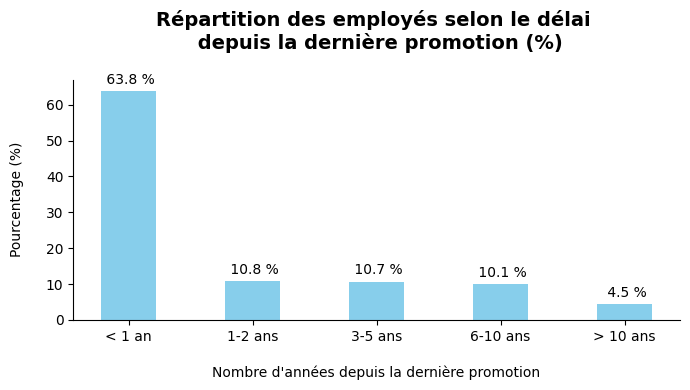

(None,)

In [35]:
yearsSinceLastPromotion_count = yearsSinceLastPromotion_count.sort_values("Tranche_LastPromotion", ascending=True)

fig , ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(yearsSinceLastPromotion_count.index))
y = yearsSinceLastPromotion_count.Pourcentage

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(yearsSinceLastPromotion_count.Tranche_LastPromotion)
ax.set_xlabel("\nNombre d'années depuis la dernière promotion")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Répartition des employés selon le délai \n depuis la dernière promotion (%)\n",
             fontsize=14,fontweight="bold")

fig.tight_layout()
plt.show(),

**Le nombre de formations suivies au cours de l'année précédente (TrainingTimesLastYear)**

**Tableau des proportions**

In [36]:
trainingTimesLastYear_count = value_counts_percent(df_conditions_travail.TrainingTimesLastYear)
trainingTimesLastYear_count

,TrainingTimesLastYear,Pourcentage
0,2,37.2
1,3,33.4
2,4,8.4
3,5,8.1
4,1,4.8
5,6,4.4
6,0,3.7


On observe qu'une large majorité des employés ont suivi **entre 2 et 3 formations** au cours de l'année écoulée représentant environ 71 % de l'effectif.
Les employés ayant suivi **entre 4 et 5 formations** représentent environs 16 % de l'effectif.

À l'inverse, une minorité d'employés n'a suivi aucune formation sur la période considérée soit environs 4 %.

**la durée de collaboration avec le manager actuel (YearsWithCurrManage)**

**Tableau des proportions**

In [37]:
yearsWithCurrManager_count = value_counts_percent(df_conditions_travail.Tranche_CurManager)
yearsWithCurrManager_count

,Tranche_CurManager,Pourcentage
0,6-10 ans,30.1
1,1-2 ans,23.4
2,< 1 ans,23.1
3,3-5 ans,18.4
4,> 10 ans,5.0


L'analyse de la durée de collaboration avec le manager actuel montre que trois tranches sont particulièrement représentées :

- **6-10 ans** regroupant environ 30 % des employés
- **1-2 ans** et **moins d'un an** représentant chacune environ 23 % de l'effectif.

La tranche **supérieure à 10 ans** apparaît comme la moins représentée, avec environ 5 % des employés.

**Mini-synthèse - Management et évolution**

L'analyse des variables liées au management et à l'évolution professionnelle montre qu'une majorité d'employés ont bénéficié **d'une promotion récente**, avec un délai inférieur à un an pour une part importante de l'effectif.

Les actions de formation sont fortement concentrées, la majorité des employés (environ 71 %) ayant suivi 2 à 3 formations au cours de l'année écoulée, tandis que les profils très peu ou très fortement formés restent minoritaires.

Enfin, la durée de collaboration avec le manager actuel se répartit entre différentes tranches d'ancienneté, la tranche de 6 à 10 ans étant la plus représentée, tandis que les collaborations de plus de 10 ans demeurent limitées.

Après avoir décrit les principales caractéristiques des conditions de travail des employés, cette section s'intéresse désormais à leur relation avec l'attrition.

L'objectif est d'observer si certaines dimensions organisationnelles telles que le poste occupé, la rémunération, l'ancienneté ou les opportunités d'évolution présentent des différences de taux d'attrition selon les groupes étudiés.


## 3. Attrition - Conditions organisationnelles

---

### 3.1 Introduction

Dans cette section, j'analyse la relation entre l'attrition et les caractéristiques des conditions de travail des employés.

##### Tableau de proportions Attrition Yes / No

In [38]:
attrition_count = value_counts_percent(df_conditions_travail['Attrition'])

attrition_count

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D'après ce tableau, le taux d'attrition global observé dans le jeu de données est d'environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.
Dans les analyses suivantes, l'accent est mis sur le taux d'attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 3.2 Analyse de l'attrition selon les variables des conditions de travail

Dans cette partie, les sous-thèmes précédemment explorés sont mobilisés afin d'analyser la relation entre les conditions de travail et l'attrition.

Certaines variables organisationnelles ont été décrites lors de l'analyse individuelle, mais n'ont pas été retenues dans l'analyse de l'attrition, en raison de distributions peu contrastées ou d'un intérêt analytique limité observé lors de l'exploration initiale.

L'analyse repose principalement sur l'observation des taux d'attrition, calculés à partir **de tableaux de proportions** et de **visualisations graphiques**, afin d'identifier des différences de comportement de départ entre les groupes.

Cette approche permet d'identifier des configurations organisationnelles associées à des niveaux d'attrition différenciés, sans chercher à établir de relation causale.

#### 3.2.1 Attrition et la structure du poste 


Dans cette partie, les variables analysés avec l'attrition sont :

1. **JobRole** 
2. **OverTime**.


**Attrition et le poste occupé**

**Tableau de proportions** ­­


In [39]:
jobrole_attrition = df_conditions_travail[["JobRole", "Attrition"]]
jobrole_attrition

# pivot table ligne = JobRole, colonne = Attrition , valeur = Pourcentage
pivot_jobrole_attrition = pivot_percent(jobrole_attrition, "JobRole","Attrition")
pivot_jobrole_attrition = pivot_jobrole_attrition.sort_values("Yes", ascending=False)
pivot_jobrole_attrition

Attrition,No,Yes
JobRole,,
Sales Representative,60.0,40.0
Laboratory Technician,76.0,24.0
Human Resources,77.0,23.0
Sales Executive,83.0,17.0
Research Scientist,84.0,16.0
Healthcare Representative,93.0,7.0
Manufacturing Director,93.0,7.0
Manager,95.0,5.0
Research Director,98.0,2.0


**Analyse de la relation entre le poste occupé et l'attrition**

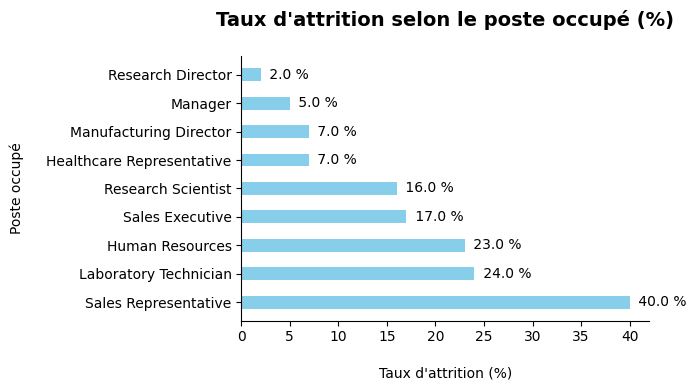

(None,)

In [40]:
fig , ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_jobrole_attrition.index))
y = pivot_jobrole_attrition["Yes"]

# Barplot

barhs = ax.barh(x, y, height=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_yticks(x)
ax.set_yticklabels(pivot_jobrole_attrition.index)

ax.set_xlabel("\nTaux d'attrition (%)")
ax.set_ylabel("Poste occupé\n")
ax.set_title("Taux d'attrition selon le poste occupé (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que le taux d'attrition est le plus élevé pour les employés occupant un poste de **Sales Representative** (40%). La fonction des **Laboratoy Technician** et des **Human Ressources** presentent un taux d'attrition élevé (entre 23 et 24 %).

À l'inverse les postes de **Research Director** (2 %) et **Manager** (5 %) ont un taux d'attrition faible.

**Attrition et les heures supplémentaires**

**Tableau de proportions**

In [41]:
overtime_attrition = df_conditions_travail[["OverTime","Attrition"]]
overtime_attrition

# Table pivot ligne = Overtime, colonne = Attrition, valeur = Pourcentage
pivot_overtime_attrition = pivot_percent(overtime_attrition, "OverTime","Attrition")
pivot_overtime_attrition = pivot_overtime_attrition.sort_values("Yes",ascending=False)
pivot_overtime_attrition

Attrition,No,Yes
OverTime,,
Yes,69.0,31.0
No,90.0,10.0


**Analyse de la relation entre les heures supplémentaires et l'attrition**

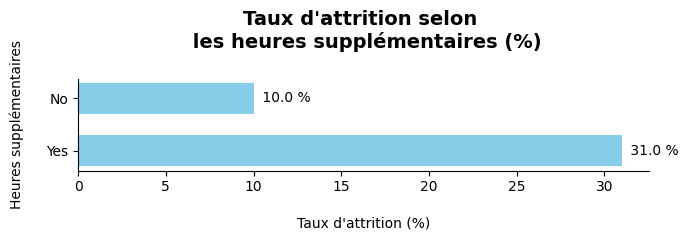

(None,)

In [42]:

fig, ax = plt.subplots(figsize=(7,2.5))


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x= np.arange(len(pivot_overtime_attrition.index))
y = pivot_overtime_attrition["Yes"]

# Barplot
barhs = ax.barh(x, y, height=0.6, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axe et label
ax.set_yticks(x)
ax.set_yticklabels(pivot_overtime_attrition.index)

ax.set_xlabel("\nTaux d'attrition (%)")
ax.set_ylabel("Heures supplémentaires\n")
ax.set_title("Taux d'attrition selon \n les heures supplémentaires (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que le taux d'attrition est plus élevé chez les employés ayant déclaré effectuer des heures supplémentaires (**31 %)**.
Toutefois, cette pratique concerne une large majorité des salariés (**≈70 %**), ce qui réduit sa capacité à distinguer efficacement les profils à risque lorsqu'elle est considérée seule.

#### 3.2.2 Attrition et la rémunération


Dans cette partie, les variables analysés avec l'attrition sont 

1. le revenu mensuel 
2. et le pourcentage d'augmentation de salaires


**Attrition et Revenu Mensuel**

**Tableau de proportions­**

In [43]:
monthlyIncome_attrition = df_conditions_travail[["Tranche_Salaire","Attrition" ]]
monthlyIncome_attrition

# Table pivot ligne = Tranche salaire, colonne = Attrition, valeur = pourcentage
pivot_monthlyIncome_attrition = pivot_percent(monthlyIncome_attrition,"Tranche_Salaire","Attrition")

pivot_monthlyIncome_attrition.sort_values("Yes",ascending=False)

Attrition,No,Yes
Tranche_Salaire,,
< 2 500,66.0,34.0
2 500 - 5 000,84.0,16.0
> 7 500,89.0,11.0
5 000 - 7 500,90.0,10.0


**Analyse de la relation entre le revenu mensuel et l'attrition**

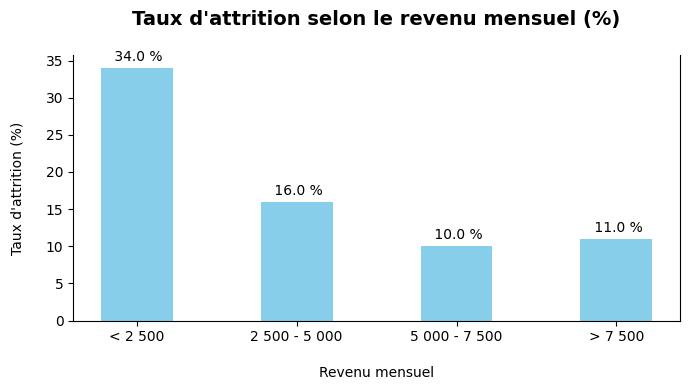

(None,)

In [44]:
pivot_monthlyIncome_attrition = pivot_monthlyIncome_attrition.sort_values("Tranche_Salaire", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["top"].set_visible(False)

# Données
x= np.arange(len(pivot_monthlyIncome_attrition.index))
y = pivot_monthlyIncome_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Affiché pourcentage
ax.bar_label(bars, labels=[f'{v : .1F} %' for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_monthlyIncome_attrition.index)

ax.set_xlabel("\nRevenu mensuel")
ax.set_ylabel("Taux d'attrition (%)\n")
ax.set_title("Taux d'attrition selon le revenu mensuel (%)\n", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

Ce graphique met en évidence que les employés ayant un revenu mensuel **inférieur à 2 500** présentent le taux d'attrition le plus élevé (**≈34 %**).

À l'inverse, le taux d'attrition est le plus faible pour la tranche de revenu **5 000 - 7 500** (≈10 %).

On observe ainsi **une diminution globale du taux d'attrition à mesure que le revenu mensuel augmente**, même si cette tendance n'est pas strictement monotone sur l'ensemble des tranches.

**Attrition et Le pourcentage d'augmentation de salaire**

**Tableau de proportions**

In [45]:
PercentSalaryHike_attrition = df_conditions_travail[["Tranche_PercentSalaryHike", "Attrition"]]
PercentSalaryHike_attrition

# Pivot table ligne= PercentSalaryHike, colonnes = Attrition, valeurs= Pourcentage

pivot_PercentSalaryHike_attrition = pivot_percent(PercentSalaryHike_attrition, "Tranche_PercentSalaryHike", "Attrition")
pivot_PercentSalaryHike_attrition.sort_values("Yes",ascending=False)

Attrition,No,Yes
Tranche_PercentSalaryHike,,
< 12,82.0,18.0
15-18,84.0,16.0
12-15,85.0,15.0
> 18,85.0,15.0


Le taux d'attrition est légèrement plus élevé pour les employés ayant bénéficié d'une augmentation de salaire **inférieure à 12 %.**

Toutefois, la distribution du taux d'attrition **reste relativement homogène entre les différentes tranches**, avec des valeurs comprises entre **15 % et 18 %**, suggérant une relation peu différenciante entre le pourcentage d'augmentation de salaire et l'attrition dans ce jeu de données.

#### 3.2.3 Attrition et Ancienneté/carrière


Dans cette partie, les variables analysés avec l'attrition sont 

1. L'ancienneté dans l'entreprise 
2. et l'ancienneté dans le poste actuel.

**Attrition et Ancienneté**

**Tableau de proportions**

In [46]:
yearsAtCompany_attrition = df_conditions_travail[["Tranche_Anciennete", "Attrition"]]
yearsAtCompany_attrition

# pivot table, ligne = ancienneté, colonnes = Attrition, valeur = pourcentage

pivot_yearsAtCompany_attrition = pivot_percent(yearsAtCompany_attrition, "Tranche_Anciennete", "Attrition")
pivot_yearsAtCompany_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
Tranche_Anciennete,,
≤ 2 ans,70.0,30.0
3-5 ans,86.0,14.0
6-10 ans,88.0,12.0
> 20 ans,88.0,12.0
16-20 ans,93.0,7.0
11-15 ans,94.0,6.0


**Analyse de la relation entre l'ancienneté et l'attrition**

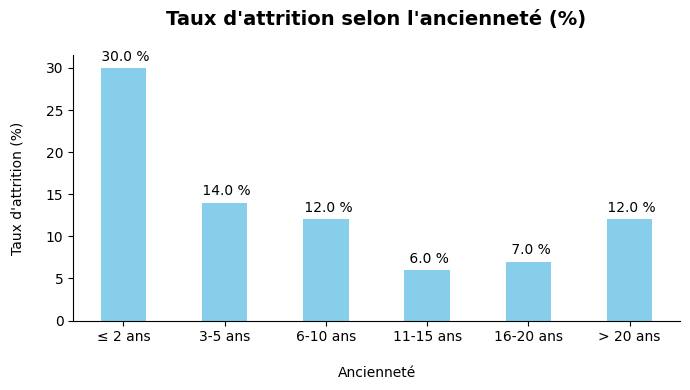

(None,)

In [47]:
fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_yearsAtCompany_attrition.index))
y =  pivot_yearsAtCompany_attrition["Yes"]

# barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y ], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_yearsAtCompany_attrition.index)

ax.set_xlabel("\nAncienneté")
ax.set_ylabel("Taux d'attrition (%)\n")
ax.set_title("Taux d'attrition selon l'ancienneté (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que le taux d'attrition est le plus élevé chez **les nouveaux salariés**, avec environ **30 %** de départs.

Le taux d'attrition diminue nettement pour les employés ayant entre **3 et 10 ans d'ancienneté**, avec des valeurs comprises entre **12 % et 14 %**, puis atteint des niveaux très faibles pour les salariés ayant une ancienneté **longue ou très longue** (environs **6 à 7 %**).

Une légère remontée du taux d'attrition est observée pour les employés ayant une ancienneté supérieure à 20 ans (≈12 %), toutefois cette tranche regroupe un effectif limité, ce qui invite à une interprétation prudente.

**Attrition et Ancienneté dans le poste**

**Tableau de proportions**


In [48]:
yearsInCurrentRole_attrition = df_conditions_travail[["Tranche_PosteAnciennete", "Attrition"]]
yearsInCurrentRole_attrition

# pivot table, ligne = ancienneté dans le poste, colonnes = Attrition, valeur = pourcentage

pivot_yearsInCurrentRole_attrition = pivot_percent(yearsInCurrentRole_attrition, "Tranche_PosteAnciennete", "Attrition")
pivot_yearsInCurrentRole_attrition

Attrition,No,Yes
Tranche_PosteAnciennete,,
≤ 2 ans,77.0,23.0
3-5 ans,88.0,12.0
6-10 ans,89.0,11.0
> 10 ans,94.0,6.0


**Analyse de la relation entre l'ancienneté dans le poste et l'attrition**

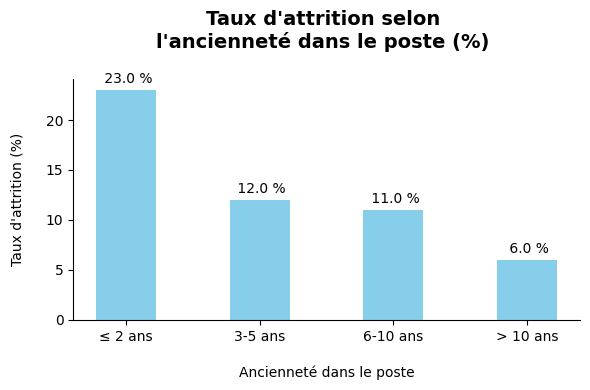

(None,)

In [49]:
fig , ax = plt.subplots(figsize=(6,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_yearsInCurrentRole_attrition.index))
y =  pivot_yearsInCurrentRole_attrition["Yes"]

# barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels 
ax.set_xticks(x)
ax.set_xticklabels(pivot_yearsInCurrentRole_attrition.index)
ax.set_xlabel("\nAncienneté dans le poste")
ax.set_ylabel("Taux d'attrition (%)\n")
ax.set_title("Taux d'attrition selon \nl'ancienneté dans le poste (%) \n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Ce graphique mets en évidence que le taux d'attrition le plus élevé est représenté par les employés dont l'ancienneté dans le poste est **inférieure à deux ans**.

À l'inverse les salariés ayant une ancienneté dans leur poste de plus de 10 ans ont le taux d'attrition le plus faible (6 %)

On observe une diminution globale du taux d'attrition à mesure que l'ancienneté dans le poste augmente.

Ce graphique met en évidence que le taux d'attrition est le plus élevé chez les employés dont l'ancienneté dans **le poste est inférieure à 2 ans** (≈23 %).
À l'inverse, les salariés occupant le même poste depuis **plus de 10 ans** présentent le taux d'attrition le plus faible (**≈6 %**).
On observe ainsi **une diminution globale du taux d'attrition à mesure que l'ancienneté dans le poste augmente**.

**Attrition et expérience professionnelle totale**

**Tableau de proportions**

In [50]:
TotalWorkingYears_attrition = df_conditions_travail[["Tranche_ExperiencePro", "Attrition"]]
TotalWorkingYears_attrition

pivot_TotalWorkingYears_attrition = pivot_percent(TotalWorkingYears_attrition, "Tranche_ExperiencePro", "Attrition")
pivot_TotalWorkingYears_attrition

Attrition,No,Yes
Tranche_ExperiencePro,,
≤ 2 ans,56.0,44.0
3-5 ans,81.0,19.0
6-10 ans,85.0,15.0
11-15 ans,87.0,13.0
> 15 ans,91.0,9.0


**Analyse de la relation entre l'expérience professionnelle et l'attrition**

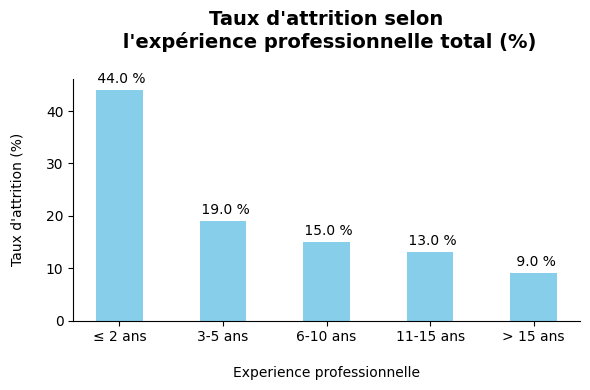

(None,)

In [51]:
fig , ax = plt.subplots(figsize=(6,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_TotalWorkingYears_attrition.index))
y =  pivot_TotalWorkingYears_attrition["Yes"]

# barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels 
ax.set_xticks(x)
ax.set_xticklabels(pivot_TotalWorkingYears_attrition.index)
ax.set_xlabel("\nExperience professionnelle")
ax.set_ylabel("Taux d'attrition (%)\n")
ax.set_title("Taux d'attrition selon\n l'expérience professionnelle total (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Le taux d'attrition varie fortement selon le niveau d'expérience professionnelle totale.

Les employés ayant **≤ 2 ans d'expérience** présentent un taux d'attrition très élevé (**44 %**).
À l'inverse, le taux d'attrition diminue progressivement avec l'augmentation de l'expérience professionnelle, pour atteindre **9 %** chez les employés ayant **plus de 15 ans d'expérience**.

Cette évolution suggère une relation inverse marquée entre l'expérience professionnelle globale et l'attrition.

#### 3.2.4 Attrition et l'évolution/Management

Dans cette partie, les variables analysés avec l'attrition sont 

1. Le délai écoulé depuis la dernière promotion 
2. la durée de collaboration avec le manager
3. 

**Attrition et le délai écoulé depuis la dernière promotion**

**Tableau de proportions**

In [52]:
YearsSinceLastPromotion_attrition = df_conditions_travail[["Tranche_LastPromotion", "Attrition"]]
YearsSinceLastPromotion_attrition

# pivot table, ligne = délai promotion, colonnes = Attrition, valeur = pourcentage

pivot_YearsSinceLastPromotion_attrition = pivot_percent(YearsSinceLastPromotion_attrition, "Tranche_LastPromotion", "Attrition")
pivot_YearsSinceLastPromotion_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
Tranche_LastPromotion,,
6-10 ans,82.0,18.0
< 1 an,83.0,17.0
1-2 ans,83.0,17.0
> 10 ans,88.0,12.0
3-5 ans,90.0,10.0


On observe des **différences modérées** de taux d'attrition selon le délai écoulé depuis la dernière promotion.

Le taux d'attrition est légèrement plus élevé pour les employés dont la dernière promotion remonte à **6-10 ans** (≈18 %), ainsi que pour ceux ayant été promus **récemment** (moins d'1 an ou 1-2 ans, ≈17 %).

À l'inverse, la tranche **3-5 ans** présente le taux d'attrition le plus faible (**≈10 %**).

Toutefois, l'absence de tendance clairement croissante ou décroissante suggère **une relation peu structurée** entre le délai depuis la dernière promotion et l'attrition.

**Attrition et la durée de collaboration avec le manager**

**Tableau de proportions**

In [53]:
yearsWithCurrManager_attrition = df_conditions_travail[["Tranche_CurManager", "Attrition"]]
yearsWithCurrManager_attrition

# pivot table , ligne = durée de collaboration, colonnes = Attrition, valeur = pourcentage
pivot_yearsWithCurrManager_attrition = pivot_percent(yearsWithCurrManager_attrition,"Tranche_CurManager", "Attrition")
pivot_yearsWithCurrManager_attrition

Attrition,No,Yes
Tranche_CurManager,,
< 1 ans,72.0,28.0
1-2 ans,85.0,15.0
3-5 ans,87.0,13.0
6-10 ans,88.0,12.0
> 10 ans,96.0,4.0


**Analyse de la relation entre la durée de collaboration avec le manager et l'attrition**

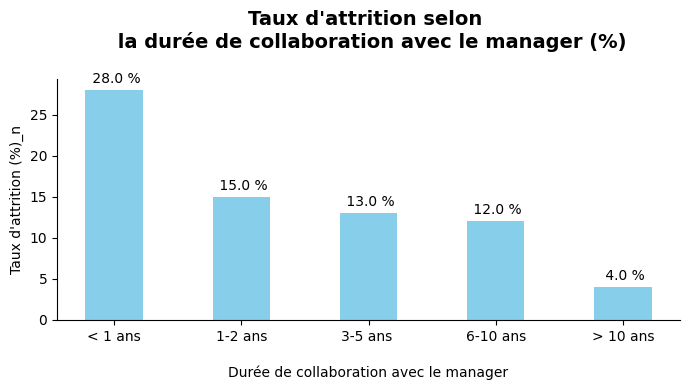

(None,)

In [54]:
fig , ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_yearsWithCurrManager_attrition.index))
y =  pivot_yearsWithCurrManager_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_yearsWithCurrManager_attrition.index)

ax.set_xlabel("\nDurée de collaboration avec le manager")
ax.set_ylabel("Taux d'attrition (%)_n")
ax.set_title("Taux d'attrition selon \n la durée de collaboration avec le manager (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Le taux d'attrition est nettement plus élevé chez les employés ayant une collaboration récente avec leur manager (< 1 an), puis diminue progressivement avec l'ancienneté managériale, atteignant un minimum pour les collaborations de plus de 10 ans.

#### 3.3 Résultats clés - Conditions de travail et attrition


Les analyses mettent en évidence plusieurs résultats marquants concernant la relation entre les conditions de travail et l'attrition.


- **L'attrition est particulièrement élevée chez les salariés en début de parcours professionnel**, qu'il s'agisse de l'ancienneté dans l'entreprise, de l'ancienneté dans le poste ou de l'expérience professionnelle globale.
À l'inverse, le taux d'attrition diminue globalement à mesure que l'ancienneté et l'expérience augmentent, traduisant **une relation inverse** entre ces variables et l'attrition.

- **Ce constat se retrouve également dans la durée de collaboration avec le manager** : plus la relation managériale est installée dans le temps, plus le taux d'attrition tend à diminuer.

- Par ailleurs, **le taux d'attrition baisse progressivement avec l'augmentation du revenu mensuel**, les salariés aux niveaux de rémunération les plus faibles présentant l**es taux de départ les plus élevés**.

- **Certains postes se distinguent par des taux d'attrition particulièrement élevés**, notamment les fonctions commerciales et les ressources humaines, et ce malgré une représentativité plus faible dans l'effectif total.

- L**es situations d'heures supplémentaires sont associées à un taux d'attrition plus élevé.** Toutefois, cette pratique étant largement répandue au sein de l'entreprise, elle apparaît peu discriminante lorsqu'elle est considérée isolément.

-**Enfin, certaines variables organisationnelles — telles que le délai écoulé depuis la dernière promotion ou le pourcentage d'augmentation de salaire — présentent des variations de taux d'attrition limitées et peu structurées**, sans différenciation nette entre les groupes.

Une fois les comparaisons simples réalisées, j'explore les relations internes à l'axe afin d'identifier d'éventuels patterns ou corrélations.

## 4. Relations internes à l'axe condition de travail

---

### 4.1 Introduction


Après avoir analysé les relations entre les variables organisationnelles et l'attrition, cette section vise à explorer les relations internes entre les variables de l'axe *Conditions de travail*, afin d'identifier d'éventuelles associations ou configurations récurrentes.

Les analyses portent sur trois relations entre variables organisationnelles, étudiées dans le but d'apporter un éclairage complémentaire aux résultats d'attrition observés précédemment :

- Relation entre l'ancienneté dans l'entreprise et l'ancienneté dans le poste  
- Relation entre l'ancienneté dans l'entreprise et la rémunération  
- Relation entre l'ancienneté dans le poste et la rémunération  

### 4.2 Analyse des relations entre variables organisationnelles
---

Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.

#### 4.2.1 Relation entre l'ancienneté dans l'entreprise et l'ancienneté dans le poste

**Tableaux croisés (%)**


In [55]:

yearsAtCompany_YearsInCurrentRole = df_conditions_travail[["Tranche_PosteAnciennete", "Tranche_Anciennete"]]
yearsAtCompany_YearsInCurrentRole

# Pivot table : ligne = ancienneté dans le poste , colonnes = Ancienneté, valeur = Pourcentage

pivot_yearsAtCompany_YearsInCurrentRole = pivot_percent(yearsAtCompany_YearsInCurrentRole, "Tranche_PosteAnciennete", "Tranche_Anciennete")
pivot_yearsAtCompany_YearsInCurrentRole

Tranche_Anciennete,≤ 2 ans,3-5 ans,6-10 ans,11-15 ans,16-20 ans,> 20 ans
Tranche_PosteAnciennete,,,,,,
≤ 2 ans,51.0,38.0,10.0,0.0,0.0,0.0
3-5 ans,0.0,65.0,32.0,1.0,0.0,1.0
6-10 ans,0.0,0.0,65.0,16.0,9.0,10.0
> 10 ans,0.0,0.0,0.0,41.0,38.0,21.0


**Visualisation**

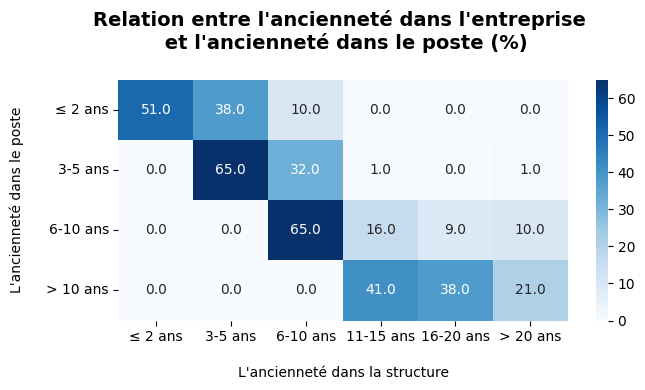

(None,)

In [56]:
plt.figure(figsize=(7,4))

sns.heatmap(pivot_yearsAtCompany_YearsInCurrentRole, cmap="Blues",annot=True, fmt=".1F", cbar=True)

plt.gca().yaxis_inverted()

plt.title("Relation entre l'ancienneté dans l'entreprise \n et l'ancienneté dans le poste (%)\n",fontsize=14, fontweight="bold" )
plt.xlabel("\nL'ancienneté dans la structure")
plt.ylabel("L'ancienneté dans le poste\n")
plt.xticks(rotation= 0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show(),


Cette visualisation met en évidence **une forte cohérence** entre l'ancienneté dans l'entreprise et l'ancienneté dans le poste occupé.

Les employés récemment arrivés dans l'entreprise (≤ 2 ans) occupent majoritairement des postes récents, tandis que les salariés ayant une ancienneté plus élevée dans la structure se concentrent progressivement dans des postes stabilisés puis plus expérimentés.

La présence **d'une diagonale marquée**, associée à de faibles concentrations hors de celle-ci, indique des parcours professionnels globalement progressifs, avec peu de décalage entre l'ancienneté globale et la durée passée dans le poste.

Cette relation décrit une organisation des parcours professionnels relativement structurée, sans présumer des mécanismes sous-jacents, à ce stade de l'analyse descriptive.

#### 4.2.2 Relation entre l'ancienneté dans l'entreprise et la rémunération


**Tableaux croisés (%)**

In [57]:
yearsAtCompany_MonthlyIncome = df_conditions_travail[["Tranche_Salaire", "Tranche_Anciennete"]]
yearsAtCompany_MonthlyIncome

# Pivot table : ligne = revenu mensuel, colonne = ancienneté , valeur = pourcentage
pivot_yearsAtCompany_MonthlyIncome = pivot_percent(yearsAtCompany_MonthlyIncome,"Tranche_Salaire", "Tranche_Anciennete")
pivot_yearsAtCompany_MonthlyIncome


Tranche_Anciennete,≤ 2 ans,3-5 ans,6-10 ans,11-15 ans,16-20 ans,> 20 ans
Tranche_Salaire,,,,,,
< 2 500,48.0,36.0,14.0,1.0,1.0,0.0
2 500 - 5 000,27.0,39.0,26.0,6.0,2.0,0.0
5 000 - 7 500,14.0,25.0,48.0,10.0,3.0,1.0
> 7 500,12.0,17.0,32.0,11.0,12.0,16.0


**Visualisation**

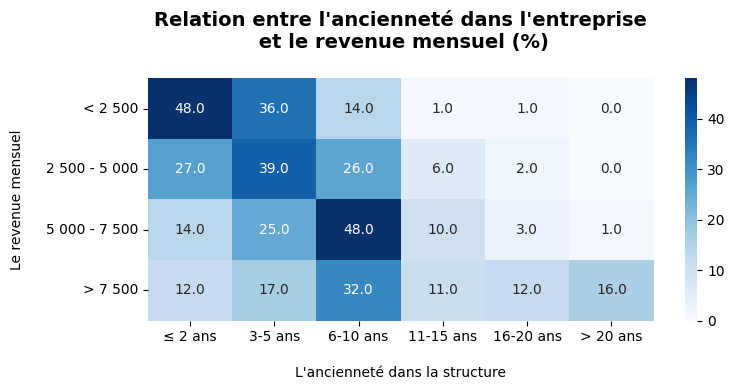

(None,)

In [58]:
plt.figure(figsize=(8,4))

sns.heatmap(pivot_yearsAtCompany_MonthlyIncome, cmap="Blues", fmt=".1F", annot=True, cbar=True)

plt.gca().yaxis_inverted()

plt.title("Relation entre l'ancienneté dans l'entreprise\n et le revenue mensuel (%)\n",fontsize=14, fontweight="bold" )
plt.xlabel("\nL'ancienneté dans la structure")
plt.ylabel("Le revenue mensuel\n")
plt.xticks(rotation= 0)
plt.yticks(rotation= 0)

plt.tight_layout()
plt.show(),

Cette visualisation met en évidence **une cohérence modérée** entre l'ancienneté dans l'entreprise et le revenu mensuel.

Les employés récemment arrivés dans l'entreprise (≤ 2 ans) sont majoritairement concentrés dans les tranches de revenu les plus faibles, tandis que les salariés ayant une ancienneté plus élevée dans la structure se répartissent davantage dans des niveaux de rémunération plus élevés.

La présence d'**une diagonale partielle** suggère une association progressive entre l'ancienneté et le niveau de rémunération, sans pour autant traduire une relation strictement linéaire.

On observe également **un étalement des niveaux de revenu** pour les salariés ayant une ancienneté élevée, notamment dans la tranche > 7 500, indiquant une hétérogénéité des rémunérations aux niveaux d'ancienneté les plus élevés.

#### 4.2.3 Relation entre l'ancienneté dans le poste et la rémunération

**Tableau croisé (%)**

In [59]:
yearsInCurrentRole_MonthlyIncome  = df_conditions_travail[["Tranche_Salaire", "Tranche_PosteAnciennete"]]
yearsInCurrentRole_MonthlyIncome

# Pivot table : ligne = revenu mensuel, colonne = ancienneté dans le poste , valeur= Pourcentage
pivot_yearsInCurrentRole_MonthlyIncome = pivot_percent(yearsInCurrentRole_MonthlyIncome, "Tranche_Salaire", "Tranche_PosteAnciennete")
pivot_yearsInCurrentRole_MonthlyIncome

Tranche_PosteAnciennete,≤ 2 ans,3-5 ans,6-10 ans,> 10 ans
Tranche_Salaire,,,,
< 2 500,75.0,17.0,7.0,1.0
2 500 - 5 000,54.0,22.0,21.0,2.0
5 000 - 7 500,34.0,24.0,36.0,5.0
> 7 500,27.0,12.0,50.0,11.0


**Visualisation**

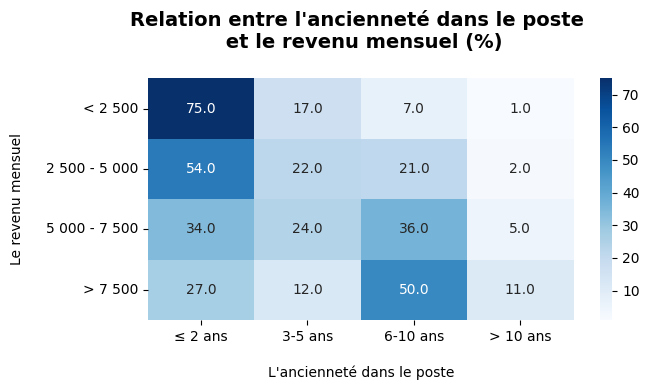

(None,)

In [60]:
plt.figure(figsize=(7,4))

sns.heatmap(pivot_yearsInCurrentRole_MonthlyIncome, cmap="Blues", fmt=".1F", annot=True, cbar=True)
plt.gca().yaxis_inverted()

plt.title("Relation entre l'ancienneté dans le poste \n et le revenu mensuel (%)\n",fontsize=14, fontweight="bold" )
plt.xlabel("\nL'ancienneté dans le poste")
plt.ylabel("Le revenu mensuel\n")

plt.tight_layout()
plt.show(),


La visualisation met en évidence **une structuration progressive** entre l'ancienneté dans le poste et le niveau de rémunération.

Les tranches de revenus les plus faibles sont majoritairement composées d'employés récemment en poste, tandis que les niveaux de rémunération plus élevés sont davantage associés à des anciennetés intermédiaires dans le poste, notamment entre 6 et 10 ans.

Toutefois, la présence d'employés récemment en poste dans l'ensemble des tranches de revenus, y compris les plus élevées, met en évidence **une hétérogénéité des trajectoires salariales**, suggérant que l'ancienneté dans le poste ne constitue pas, à elle seule, un facteur exclusif de structuration de la rémunération.

Après avoir analysé ces trois relations, cette section synthétise les principaux patterns observés.

### 4.3 Synthèse des patterns observés

Les analyses des relations internes à l'axe *Condition de travail* mettent en évidence plusieurs patterns structurants :

- **Pattern 1 - Progression structurée des parcours internes**  
  La relation entre l'ancienneté dans l'entreprise et l'ancienneté dans le poste montre une progression globalement cohérente des parcours professionnels.

  Les employés récemment arrivés occupent majoritairement des postes récents, tandis que les salariés ayant une ancienneté plus élevée dans l'entreprise se concentrent progressivement dans des postes stabilisés puis très expérimentés.

  La présence d'une diagonale marquée dans les tableaux croisés suggère une organisation des parcours internes progressive et relativement structurée, avec peu de décalage entre ancienneté globale et durée passée dans le poste.


- **Pattern 2 - Progression salariale globalement associée à l'ancienneté**  
 
  La rémunération tend à augmenter avec l'ancienneté dans l'entreprise et dans le poste, traduisant une association globale entre le temps passé et le niveau de rémunération.

  Cette relation reste toutefois modérée et non strictement linéaire. Les niveaux de rémunération les plus élevés présentent une dispersion plus importante, indiquant une hétérogénéité des trajectoires salariales aux niveaux d'ancienneté élevés.


- **Pattern 3 - Hétérogénéité des trajectoires salariales à ancienneté comparable**  
  Les analyses montrent également la présence d'employés récemment en poste ou récemment arrivés dans l'entreprise dans l'ensemble des tranches de rémunération, y compris les plus élevées.

  Cette dispersion suggère que, si l'ancienneté constitue un facteur explicatif important de la rémunération, elle n'est pas exclusive. D'autres dimensions organisationnelles, telles que le poste occupé, le niveau hiérarchique ou le parcours professionnel, semblent également intervenir dans la structuration des niveaux de salaire.

  Ces patterns internes permettent de mieux contextualiser les résultats observés sur l'attrition, notamment la plus forte exposition des salariés en début de parcours et aux niveaux de rémunération les plus faibles.
---


# 5. Résultats clés 

---

- **Ancienneté, carrière et management**  
  L'attrition est fortement concentrée sur les salariés en début de parcours professionnel qu'il s'agisse de l'ancienneté dans l'entreprise, dans le poste ou de la durée de collaboration avec le manager.  
  Ce résultat souligne l'importance des premières années et des premières relations managériales dans la dynamique de départ.

- **Rémunération**  
  Les niveaux de rémunération apparaissent comme un facteur structurant de l'attrition : les salariés aux revenus les plus faibles présentent les taux de départ les plus élevés.

- **Structure du poste**  
  Certaines fonctions spécifiques, notamment commerciales et ressources humaines, se distinguent par des taux d'attrition particulièrement élevés, indépendamment de leur poids dans l'effectif total.  
  Les heures supplémentaires sont également associées à un taux d'attrition plus élevé, mais leur généralisation limite leur capacité explicative lorsqu'elles sont considérées isolément.

- **Évolution formelle**  
  Les variables liées à l'évolution formelle (augmentation salariale, délai depuis la dernière promotion) présentent des effets plus modérés et peu structurés sur l'attrition.

---


# 5. Conclusion de l'axe “Condition de travail”
---

Cet axe s'est concentré sur l'analyse des caractéristiques organisationnelles des employés, à travers quatre dimensions : la structure du poste, la rémunération, l'ancienneté et la carrière, ainsi que le management et les opportunités d'évolution.

L'analyse de ces variables, croisées avec l'attrition, met en évidence que certaines conditions de travail structurent fortement les départs, en particulier celles liées au début du parcours professionnel, à la rémunération et à certaines fonctions spécifiques. Ces résultats permettent d'identifier des profils plus exposés à l'attrition, sans logique de stigmatisation, mais selon des configurations organisationnelles observables.

Toutefois, l'analyse de cet axe prise isolément ne permet pas d'expliquer l'ensemble des comportements de départ. Si certaines variables présentent des relations claires avec l'attrition, d'autres montrent des effets plus modérés ou hétérogènes, suggérant que des facteurs complémentaires interviennent dans la décision de quitter l'entreprise.

Ainsi, l'étude des conditions de travail apporte une vision du **contexte organisationnel** et permet de répondre partiellement à la question *« comment les départs s'opèrent »*. Elle ne permet cependant pas d'appréhender le ressenti des employés face à ces conditions ni leur impact sur la décision individuelle de départ.

L'analyse de l'attrition doit donc être complétée par l'étude de la **satisfaction** et de **l'implication**, qui constituent des leviers centraux dans la compréhension des comportements de départ.

---
